# Unsupervised Hypersphere Fitting Algorithm

This notebook implements and adapts ideas from A classification method based on a cloud of spheres [ ]. The original work proposes constructing spherical regions to define decision boundaries between classes. In this project, the method is adapted for unsupervised anomaly detection using MVTec AD and DINOv2 embeddings.

The original paper differs from this setting in two important ways:

- Supervised boundary construction: 
The original algorithm uses both positive and negative classes when forming spheres. In this project, only normal training samples are available, so the sphere boundaries must be estimated without defective samples. To address this, candidate regions are initialised from local KNN density and then expanded using a constrained growth step.

- Connected manifold assumption:
The original method assumes that the data lie on a shared manifold and encourages connected spherical regions. This assumption is less appropriate here because DINOv2 produces 768-dimensional general-purpose embeddings. A single object category may occupy several disconnected regions in this embedding space. Therefore, the adapted algorithm does not require spheroids to be connected.

- Exclusive embedding assignment
The adapted algorithm enforces that each normal training embedding belongs to exactly one spheroid. During the growth stage, candidate regions are iteratively cleaned to ensure that previously assigned embeddings are not incorporated into newly generated spheroids. While geometric overlap between spheroids is permitted, overlap in embedding ownership is not. This results in a unique partitioning of the normal embedding space while still allowing neighbouring regions to share empty areas of the embedding space.

In [10]:
import os

import torch
import sqlite3
import pandas as pd
import numpy as np

import json

from datetime import datetime
from dataclasses import asdict

from itertools import combinations

from pathlib import Path
import sys 

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, EXPERIMENTS, RESULTS, DB_PATH, IMAGES, CACHES
from src.algorithims.utils import get_category_masks

EMBED_PATH = EMBEDS_DIR / "base_embeds"
EMBED_NAME = EMBED_PATH.stem

EXPERIMENTS_DIR = EXPERIMENTS / EMBED_NAME / "hypersphere"
RESULTS_DIR = RESULTS / EMBED_NAME

IMAGE_DIR = IMAGES / EMBED_NAME
CACHE_DIR = CACHES / EMBED_NAME

In [11]:
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(EXPERIMENTS_DIR, exist_ok=True)

In [12]:
cls_tokens = torch.load(EMBED_PATH/"cls.pt", weights_only=False)

In [13]:
conn = sqlite3.connect(DB_PATH)

meta = pd.read_sql_query("SELECT * FROM meta", conn)
categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()

conn.close()

In [14]:
%load_ext autoreload
%autoreload 2

from src.plots.hypersphere_plots import plot_ellipsoid, plot_K, plot_growth_rates, plot_sphere_cover, plot_3d_sphere_cover

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## How does Mahlanobis fit to the data

This section visualises how a global Mahalanobis ellipsoid fits the normal training embeddings and uses it as a baseline for comparison with the proposed hypersphere fitting algorithm.

The objective is not to evaluate the performance of Mahalanobis, but rather to understand the assumptions it makes about the embedding space. In particular, Mahalanobis models the normal distribution as a single ellipsoidal region defined by the global centroid and covariance matrix. The following visualisations illustrate how well this assumption represents the underlying embedding distribution before introducing the proposed multi-region fitting approach.

Computing  /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/data/cache/base_embeds/cls_pca.npy


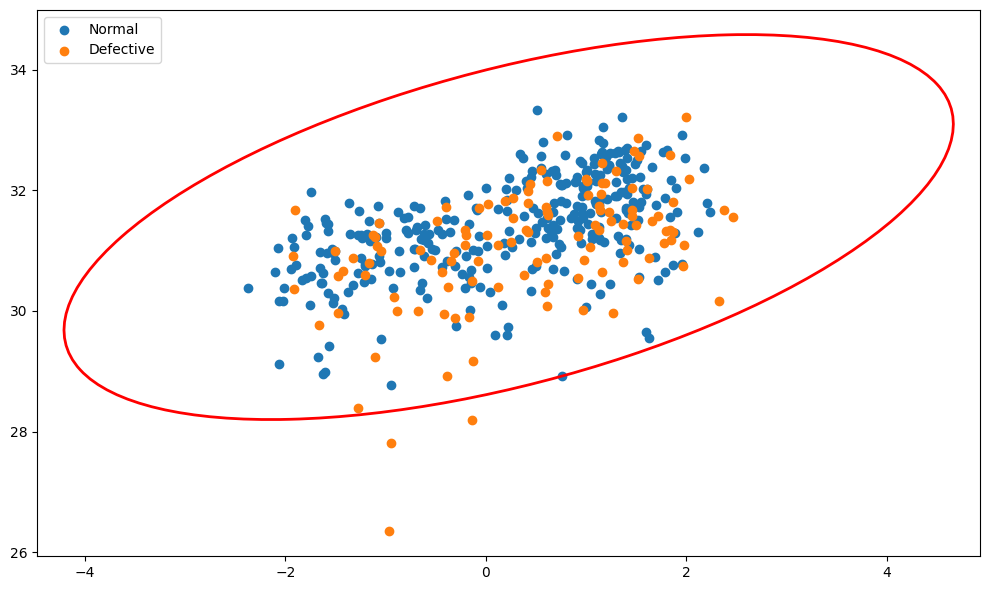

In [15]:
masks = get_category_masks(category="screw", meta=meta)

plot_ellipsoid(cls_tokens, masks, output_dir=IMAGE_DIR, cache_dir=CACHE_DIR)

## Choosing a Value for K

The first step of the proposed algorithm is identifying the densest local region of the normal embedding space. This is achieved using a K-nearest neighbours (KNN) search, where the embedding with the smallest average distance to its neighbours is selected as the initial sphere centre.

Selecting an appropriate value for K is important. If K is too small, the initial neighbourhood becomes overly sensitive to local noise and may fail to capture a representative region. Conversely, if K is too large, the neighbourhood becomes overly broad, increasing the likelihood of creating a hypersphere that encompasses a significant proportion of the embedding space.

As each MVTec AD category contains a different number of normal training samples, selecting a fixed value of K would not scale consistently across categories. Instead, K is defined as a percentage of the available training embeddings. Three candidate values (2.5%, 5%, and 10%) are visually compared to determine a suitable compromise between capturing a dense local neighbourhood while avoiding an overly large initial region.

Loading  /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/data/cache/base_embeds/cls_pca.npy
Cat length:  320
frac: 0.025
K: 8
most compact idx: 93
avg KNN dist: 51.533134
frac: 0.05
K: 16
most compact idx: 93
avg KNN dist: 59.036354
frac: 0.1
K: 32
most compact idx: 93
avg KNN dist: 73.15103


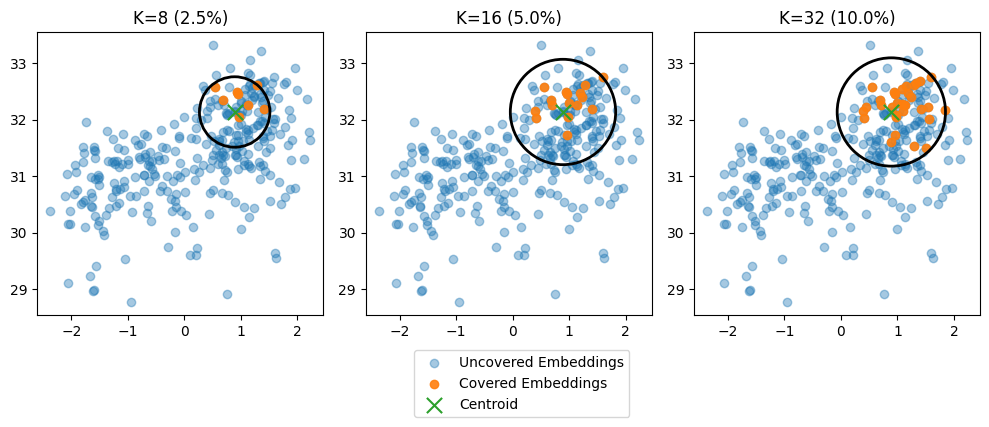

In [16]:
plot_K(masks=masks, cls_tokens=cls_tokens, output_dir=IMAGE_DIR, cache_dir=CACHE_DIR)

The value in the end selected was 5% of the available training embeddings. Visually, this provided the best balance between capturing a representative local neighbourhood while avoiding an initial hypersphere that encompassed an excessively large region of the embedding space.

Although this percentage is unlikely to be optimal for every category, as the structure of the embedding space varies between object classes, it provides a consistent and scalable initialisation strategy across the MVTec AD dataset. Furthermore, the subsequent growth stage allows the hypersphere to adapt to the local embedding distribution, reducing the sensitivity of the overall algorithm to the initial choice of K.

## Growth Rate for the Hyperspheres

Although the initial KNN neighbourhood provides a suitable starting point, the choice of K remains arbitrary and should not solely determine the size of a hypersphere. To reduce the dependence on this initial neighbourhood, a growth stage is introduced.

Starting from the initial KNN region, the hypersphere is iteratively expanded by a small growth factor. After each expansion, any newly enclosed embeddings are incorporated into the region and the hypersphere is recalculated using the updated centroid and radius. This process continues until no additional embeddings can be added.

The purpose of the growth stage is to allow each hypersphere to adapt naturally to the local structure of the embedding space rather than being constrained by the initial KNN selection. In particular, it reduces the likelihood of producing a large number of singleton or very small hyperspheres, allowing neighbouring embeddings that belong to the same local region to be grouped together.

Loading  /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/data/cache/base_embeds/cls_pca.npy
Cat length:  320
RUN:  1
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (17, 2)
Growth:  1.0
RUN:  1
RUN:  2
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (18, 2)
Growth:  1.025
RUN:  1
RUN:  2
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (20, 2)
Growth:  1.05
RUN:  1
RUN:  2
RUN:  3
RUN:  4
RUN:  5
RUN:  6
RUN:  7
RUN:  8
RUN:  9
RUN:  10
RUN:  11
RUN:  12
RUN:  13
RUN:  14
RUN:  15
RUN:  16
RUN:  17
RUN:  18
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (320, 2)
Growth:  1.1


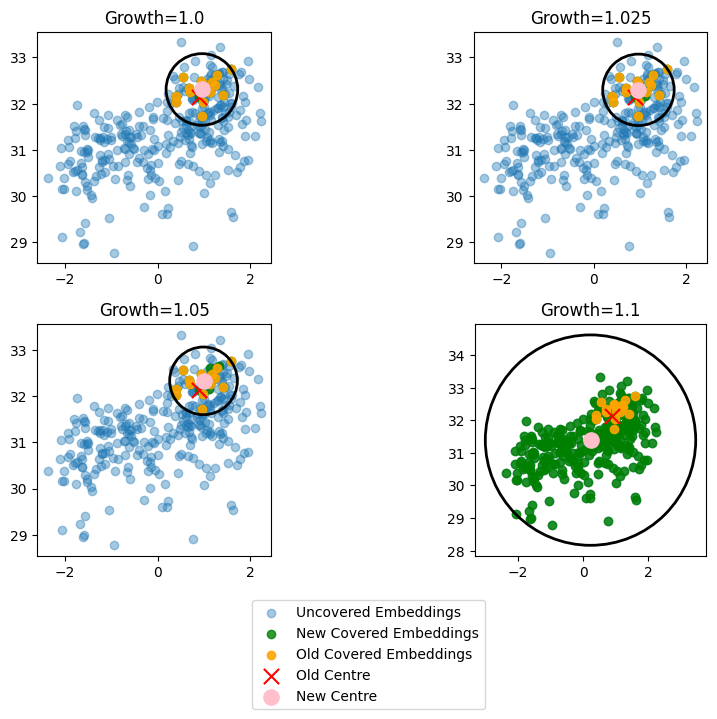

In [17]:
plot_growth_rates(masks, cls_tokens, output_dir=IMAGE_DIR, cache_dir=CACHE_DIR)

A growth rate of 5% was selected as the most suitable value. This provided enough expansion to include additional nearby embeddings from the same local neighbourhood, while avoiding excessive growth. A smaller growth rate of 2.5% produced little change from the initial KNN region, whereas a larger growth rate of 10% caused the hypersphere to expand too broadly, creating a catch-all region. This behaviour would reduce the benefit of the proposed method, as the resulting hypersphere would begin to resemble a global centroid-based model rather than a local region-based representation.

#

In [18]:
%load_ext autoreload
%autoreload 2

from src.algorithims.hypersphere import CandidateCleaner, HypersphereEvaluator, HypersphereCover
from src.types import ExperimentConfig, AlgorithmResults

metadata = ExperimentConfig(
    K_frac=0.05,
    start_growth=1.05,
    min_growth=1
)

cleaner = CandidateCleaner()
cover = HypersphereCover(cleaner=cleaner)

eval = HypersphereEvaluator()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Adaptive Multi-Hypersphere Fitting

This cell implements the full unsupervised hypersphere fitting algorithm. The aim is to cover all normal training embeddings using a set of local hyperspheres, while ensuring that each training embedding is assigned to only one region.

The algorithm proceeds as follows:

1. **Initialise uncovered embeddings**  
   All normal embeddings begin as uncovered. A boolean mask is used to track which embeddings have not yet been assigned to a hypersphere.

2. **Find the densest uncovered region**  
   For the current set of uncovered embeddings, a FAISS KNN search is performed. The embedding with the smallest average distance to its neighbours is selected as the centre of the densest local  region.

3. **Create an initial candidate hypersphere**  
   The densest embedding and its nearest neighbours form the first candidate region. This candidate is cleaned to ensure it does not contain embeddings already assigned to previous hyperspheres.

4. **Grow the candidate hypersphere**  
   If the initial candidate is valid, the hypersphere is expanded using a small growth factor. Newly included uncovered embeddings are added to the candidate region.

5. **Clean after growth**  
   After each growth step, the candidate is cleaned again. If the cleaned candidate contains more embeddings than before, the growth is accepted. Otherwise, growth stops.

6. **Store the final hypersphere**  
   Once no further valid growth is possible, the final centroid, radius, and assigned embedding indices are stored. These embeddings are then marked as covered.

7. **Repeat until full coverage**  
   The process repeats until every normal training embedding has been assigned to a hypersphere.

In [23]:
time = datetime.now().strftime("%y-%m-%d_%H-%M-%S")

aurocs = {}
all_overlaps = {}
all_spheres = {}

for category in categories:
    print("Running", category)
    outputs_dir = EXPERIMENTS_DIR / category / time
    os.makedirs(outputs_dir, exist_ok=True)

    cat_masks = get_category_masks(category=category, meta=meta)
    train_embed = cls_tokens[masks.train_mask]
    cat_emb = train_embed[masks.train_category_mask]
    
    spheres, spheres_df = cover.run(
        embeds=cat_emb, output_dir=outputs_dir,
        k_frac=metadata.K_frac,
        start_growth=metadata.start_growth, min_growth=metadata.min_growth
        )
    
    all_spheres[category] = spheres
    
    test_emb = cls_tokens[cat_masks.test_mask]
    defect_test_emb = test_emb[cat_masks.defect_test_mask]
    good_test_emb = test_emb[cat_masks.good_test_mask]

    overlaps_df = eval.overlaps(cat_emb, spheres)
    overlaps_df.to_csv(outputs_dir / "overlaps.csv", index=False)

    all_overlaps[category] = overlaps_df

    good_any, good_counts = eval.inside_any_count(good_test_emb, spheres)
    defect_any, defect_counts = eval.inside_any_count(defect_test_emb, spheres)

    auroc = eval.scores(good_test_emb, defect_test_emb, spheres)
    aurocs[category] = auroc

    results = AlgorithmResults(
        config=metadata,
        category=category,
        n_shapes=len(spheres),
        auroc=auroc,
        normal_inside=int(good_any.sum()),
        defect_inside=int(defect_any.sum())
    )

    with open(outputs_dir / "metadata.json", "w") as f:
        json.dump(asdict(results), f)

aurocs_df = pd.DataFrame(aurocs.items(), columns=["Category", "AUROC"])


Running bottle
Running cable
Running capsule
Running carpet
Running grid
Running hazelnut
Running leather
Running metal_nut
Running pill
Running screw
Running tile
Running toothbrush
Running transistor
Running wood
Running zipper


In [24]:
df_roc_stats = pd.DataFrame({
    "mean": aurocs_df["AUROC"].mean(),
    "median": aurocs_df["AUROC"].median(),
    "std": aurocs_df["AUROC"].std(),
    "min_cat":  aurocs_df["Category"][aurocs_df["AUROC"].idxmin()],
    "min": aurocs_df["AUROC"].min(),
    "max_cat": aurocs_df["Category"][aurocs_df["AUROC"].idxmax()],
    "max": aurocs_df["AUROC"].max()
}, index=[0]).round(3)

df_roc_stats.to_csv(RESULTS_DIR / "hypersphere_auroc_stats.csv", index=False)

aurocs_df = aurocs_df.round(3)
aurocs_df.to_csv(RESULTS_DIR /"hypersphere_aurocs.csv", index=False)

df_roc_stats

,mean,median,std,min_cat,min,max_cat,max
0,0.477,0.506,0.178,bottle,0.152,screw,0.778


## Algorithm Test

This section tests the fitted hyperspheres by checking all pairwise combinations for geometric overlap and embedding overlap.

Geometric overlap between hyperspheres is permitted in this algorithm. Preventing all overlap would make the model overly strict, particularly in sparse regions of the embedding space, and could lead to a large number of singleton hyperspheres. Instead, the algorithm only prevents embedding overlap, meaning that a normal training embedding should not be contained within more than one hypersphere.

This distinction allows neighbouring hyperspheres to overlap in empty embedding space while still maintaining a unique assignment for each normal training sample.

In [25]:
overlap_df = all_overlaps["screw"]

print("Number of embedding overlaps:", overlap_df["overlap"].sum())
display(overlap_df, exclude=None)

Number of embedding overlaps: 512


,sphere_i,sphere_j,centre_dist,add_radii,overlap,overlap_amount,j_points_inside_i,i_points_inside_j
0,0,1,0.000000,17.608416,True,17.608416,20,20
1,0,2,21.534950,17.608416,False,0.000000,0,0
2,0,3,18.946445,17.608416,False,0.000000,0,0
3,0,4,13.807432,17.608416,True,3.800983,0,0
4,0,5,15.939409,17.608416,True,1.669006,0,0
...,...,...,...,...,...,...,...,...
1535,52,54,9.800071,17.608416,True,7.808345,0,0
1536,52,55,24.994295,17.608416,False,0.000000,0,0
1537,53,54,9.800071,17.608416,True,7.808345,0,0
1538,53,55,24.994295,17.608416,False,0.000000,0,0


Loading  /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/data/cache/base_embeds/cls_pca.npy


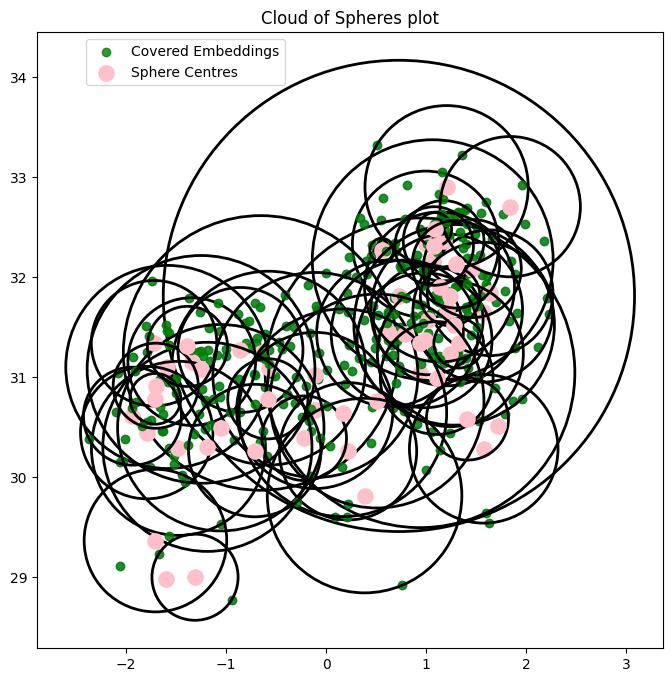

In [27]:
plot_sphere_cover(cls_tokens, masks, all_spheres[masks.category], output_dir=IMAGE_DIR, cache_dir=CACHE_DIR)

In [ ]:
plot_3d_sphere_cover(cls_tokens, masks, all_spheres[masks.category], output_dir=IMAGE_DIR, cache_dir=CACHE_DIR)